<a href="https://colab.research.google.com/github/VanshikaDhiman14/Computer-Vision-Labsheets/blob/main/Labsheet5cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Labsheet 5 Computer Vision
((Vanshika Dhiman (CU24250228))

 1. Build a keypoint detector and visualizer using SIFT, displaying detected keypoints with their scale and orientation.


Number of keypoints detected : 52933


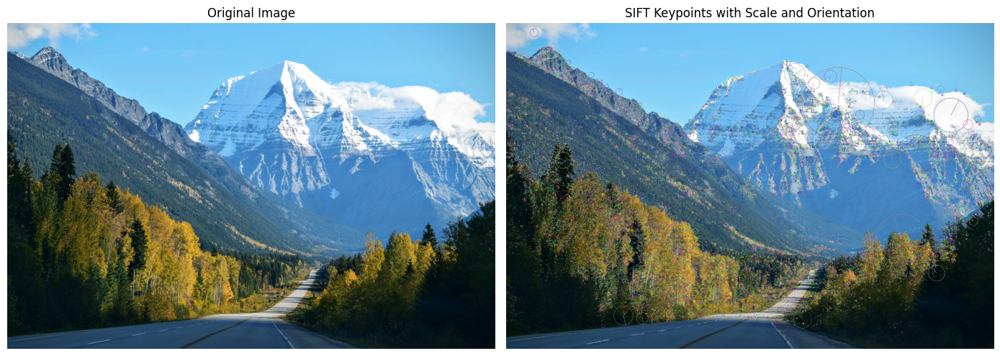


First 10 Keypoints:
----------------------------------------------------------------------
Index	X	Y	Scale	Orientation
----------------------------------------------------------------------
1	2.32	622.62	2.13	260.82°
2	2.43	426.39	1.93	156.73°
3	2.82	1656.12	1.84	142.76°
4	2.93	1658.92	1.85	181.11°
5	2.93	1658.92	1.85	267.03°
6	3.00	542.35	2.49	263.56°
7	3.13	639.81	2.30	17.15°
8	3.13	639.81	2.30	183.59°
9	3.15	434.07	2.35	198.75°
10	3.15	434.07	2.35	331.75°
Vanshika Dhiman(CU24250228)


In [ ]:
import matplotlib.pyplot as plt
import cv2
image=cv2.imread("image.jpg")
if image is None:
  print("Image not found!")
else:
  image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
  sift=cv2.SIFT_create()
  keypoints,descriptors=sift.detectAndCompute(gray,None)
  print("Number of keypoints detected :",len(keypoints))
  output_image=cv2.drawKeypoints(
      image_rgb,
      keypoints,
      None,
      flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
  )
  plt.figure(figsize=(14,6))
  plt.subplot(1,2,1)
  plt.imshow(image_rgb)
  plt.title("Original Image")
  plt.axis("off")
  plt.subplot(1, 2, 2)
  plt.imshow(output_image)
  plt.title("SIFT Keypoints with Scale and Orientation")
  plt.axis("off")

  plt.tight_layout()
  plt.show()

  # Display information about first 10 keypoints
  print("\nFirst 10 Keypoints:")
  print("-" * 70)
  print("Index\tX\tY\tScale\tOrientation")
  print("-" * 70)

  for i, kp in enumerate(keypoints[:10]):
     x, y = kp.pt
     print(f"{i+1}\t{x:.2f}\t{y:.2f}\t{kp.size:.2f}\t{kp.angle:.2f}°")
print("Vanshika Dhiman(CU24250228)")

2. Develop an image-matching tool thta uses SIFT descriptors to find and draw correspondencies between two photosof the same scene.

Keypoints in Image 1: 1432
Keypoints in Image 2: 1969
Good matches found: 34


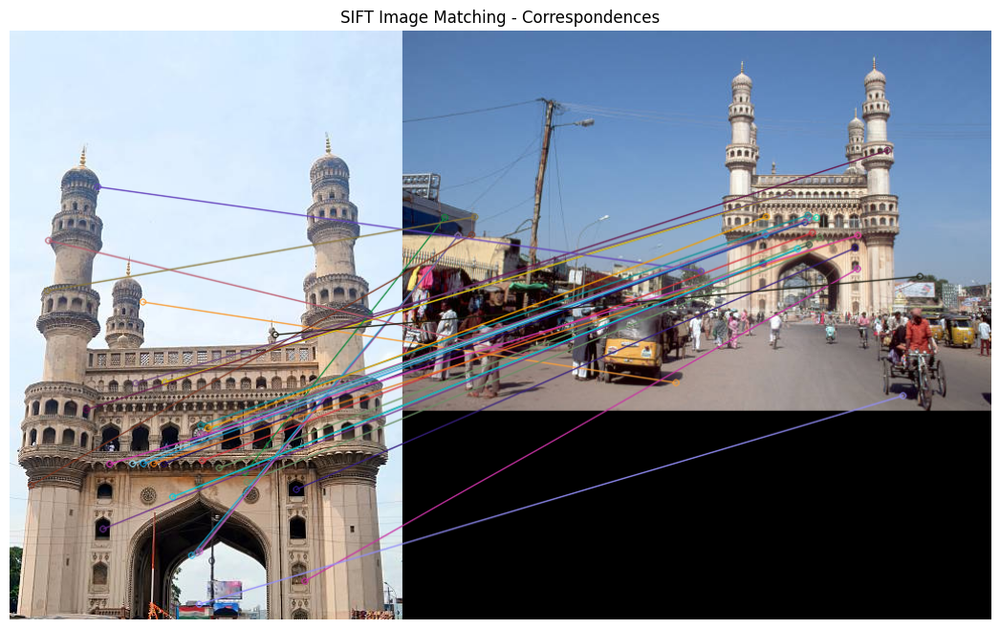

Vanshika Dhiman(CU24250228)


In [ ]:
import cv2
import matplotlib.pyplot as plt
image1=cv2.imread("charminar1.jpg")
image2=cv2.imread("charminar2.jpg")
if image1 is None or image2 is None:
  print("Error: One or both images could not be loaded")
else:
  gray1=cv2.cvtColor(image1,cv2.COLOR_BGR2GRAY)
  gray2=cv2.cvtColor(image2,cv2.COLOR_BGR2GRAY)
  sift = cv2.SIFT_create()
  # Detect keypoints and compute SIFT descriptors
  keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
  keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

  print("Keypoints in Image 1:", len(keypoints1))
  print("Keypoints in Image 2:", len(keypoints2))

  # Create BFMatcher using Euclidean distance
  bf = cv2.BFMatcher()

  # Find the two nearest matches for each descriptor
  matches = bf.knnMatch(descriptors1, descriptors2, k=2)

  # Apply Lowe's ratio test to select good matches
  good_matches = []

  for m, n in matches:
      if m.distance < 0.75 * n.distance:
          good_matches.append(m)

  print("Good matches found:", len(good_matches))

  # Draw the best matches
  good_matches = sorted(good_matches, key=lambda x: x.distance)
  # Display top matches
  output = cv2.drawMatches(
      image1,
      keypoints1,
      image2,
      keypoints2,
      good_matches[:50],
      None,
      flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
  )
  output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

  # Display result
  plt.figure(figsize=(18, 8))
  plt.imshow(output_rgb)
  plt.title("SIFT Image Matching - Correspondences")
  plt.axis("off")
  plt.show()
print("Vanshika Dhiman(CU24250228)")

3. Create a simple parnorama stitcher using SIFT feature macthing and homography estimation.

Keypoints in Image 1: 1432
Keypoints in Image 2: 1969
Good matches: 34

Homography Matrix:
[[ 7.43835133e-01  1.59780373e-01  2.92304807e+02]
 [ 1.05803867e-01  6.42440172e-01 -5.45105790e+01]
 [ 3.72715722e-04  3.03357346e-04  1.00000000e+00]]


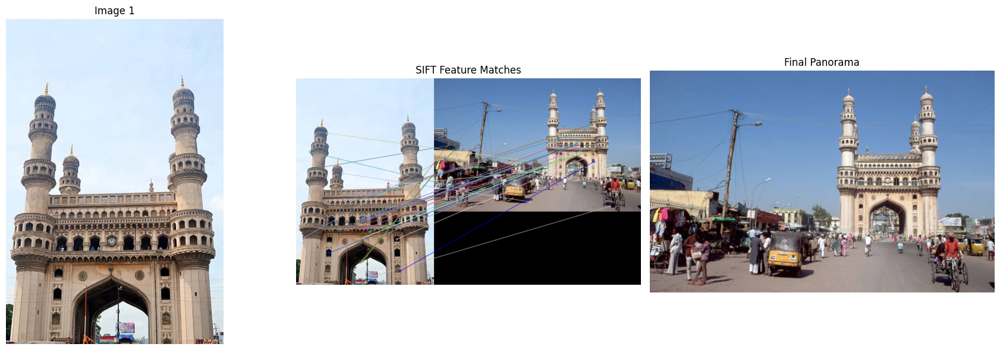


Panorama saved as: panorama.jpg
Vanshika Dhiman(CU24250228)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image1=cv2.imread("charminar1.jpg")
image2=cv2.imread("charminar2.jpg")
if image1 is None or image2 is None:
    print("Error: Could not load one or both images.")
else:
  img1_rgb=cv2.cvtColor(image1,cv2.COLOR_BGR2RGB)
  img2_rgb=cv2.cvtColor(image2,cv2.COLOR_BGR2RGB)

  gray1=cv2.cvtColor(image1,cv2.COLOR_BGR2GRAY)
  gray2=cv2.cvtColor(image2,cv2.COLOR_BGR2GRAY)

  sift=cv2.SIFT_create()
  keypoints1,descriptors=sift.detectAndCompute(gray1,None)
  keypoints2,descriptors=sift.detectAndCompute(gray2,None)
  print("Keypoints in Image 1:", len(keypoints1))
  print("Keypoints in Image 2:", len(keypoints2))
  # Match sift descriptors
  bf=cv2.BFMatcher()
  matches=bf.knnMatch(descriptors1,descriptors2,k=2)
  #Lowe's ratio test
  good_matches=[]
  for m,n in matches:
    if m.distance<0.75* n.distance:
      good_matches.append(m)
  print("Good matches:",len(good_matches))
  if(len(good_matches)<4):
    print("Not enough matches to calculate homography.")
  else:
        match_image = cv2.drawMatches(
            image1,
            keypoints1,
            image2,
            keypoints2,
            good_matches[:50],
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        match_image_rgb = cv2.cvtColor(
            match_image, cv2.COLOR_BGR2RGB
        )
        src_points = np.float32([
            keypoints1[m.queryIdx].pt for m in good_matches
        ]).reshape(-1, 1, 2)

        dst_points = np.float32([
            keypoints2[m.trainIdx].pt for m in good_matches
        ]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(
            src_points,
            dst_points,
            cv2.RANSAC,
            5.0
        )

        if H is None:
            print("Homography could not be calculated.")

        else:
            print("\nHomography Matrix:")
            print(H)

            h1, w1 = image1.shape[:2]
            h2, w2 = image2.shape[:2]

            # Warp image1 to image2's perspective
            panorama = cv2.warpPerspective(
                image1,
                H,
                (w1 + w2, max(h1, h2))
            )

            panorama[0:h2, 0:w2] = image2
            gray_panorama = cv2.cvtColor(
                panorama,
                cv2.COLOR_BGR2GRAY
            )

            _, thresh = cv2.threshold(
                gray_panorama,
                1,
                255,
                cv2.THRESH_BINARY
            )

            contours, _ = cv2.findContours(
                thresh,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            if contours:
                x, y, w, h = cv2.boundingRect(
                    max(contours, key=cv2.contourArea)
                )

                panorama = panorama[y:y+h, x:x+w]
            panorama_rgb = cv2.cvtColor(
                panorama,
                cv2.COLOR_BGR2RGB
            )
            plt.figure(figsize=(18, 6))

            plt.subplot(1, 3, 1)
            plt.imshow(img1_rgb)
            plt.title("Image 1")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(match_image_rgb)
            plt.title("SIFT Feature Matches")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(panorama_rgb)
            plt.title("Final Panorama")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
            cv2.imwrite("panorama.jpg", panorama)

            print("\nPanorama saved as: panorama.jpg")
print("Vanshika Dhiman(CU24250228)")

4. Build a logo or object loader that finds a reference object inside a cluttered scene using SIFT feature matching.

Reference keypoints: 439
Scene keypoints: 3563
Good matches: 83
Inlier matches: 49
Object detected successfully!


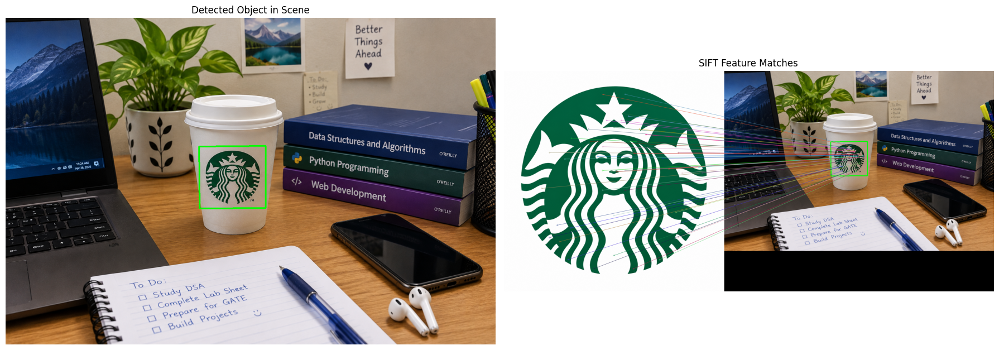

Vanshika Dhiman(CU24250228)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
reference = cv2.imread("img5.png")
scene = cv2.imread("img6.png")

if reference is None or scene is None:
    print("Error: Could not load one or both images.")
else:

    # Convert to grayscale
    gray_reference = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
    gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)

    # ---------------------------------------------------
    # 2. Create SIFT detector
    # ---------------------------------------------------

    sift = cv2.SIFT_create()

    # Detect keypoints and descriptors
    kp1, des1 = sift.detectAndCompute(gray_reference, None)
    kp2, des2 = sift.detectAndCompute(gray_scene, None)

    print("Reference keypoints:", len(kp1))
    print("Scene keypoints:", len(kp2))

    # ---------------------------------------------------
    # 3. Match SIFT descriptors
    # ---------------------------------------------------

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    # Lowe's ratio test
    good_matches = []

    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    print("Good matches:", len(good_matches))

    # ---------------------------------------------------
    # 4. Find the object in the scene
    # ---------------------------------------------------

    if len(good_matches) >= 4:

        # Coordinates of matching points
        src_pts = np.float32([
            kp1[m.queryIdx].pt for m in good_matches
        ]).reshape(-1, 1, 2)

        dst_pts = np.float32([
            kp2[m.trainIdx].pt for m in good_matches
        ]).reshape(-1, 1, 2)

        # Calculate homography using RANSAC
        H, mask = cv2.findHomography(
            src_pts,
            dst_pts,
            cv2.RANSAC,
            5.0
        )

        if H is not None:

            # Get dimensions of reference image
            h, w = gray_reference.shape

            # Reference image corners
            corners = np.float32([
                [0, 0],
                [w, 0],
                [w, h],
                [0, h]
            ]).reshape(-1, 1, 2)

            # Transform corners to scene
            transformed_corners = cv2.perspectiveTransform(
                corners,
                H
            )

            # Draw bounding box around detected object
            scene_result = scene.copy()

            cv2.polylines(
                scene_result,
                [np.int32(transformed_corners)],
                True,
                (0, 255, 0),
                4
            )

            # Draw only inlier matches
            inlier_matches = []

            for i, m in enumerate(good_matches):
                if mask[i]:
                    inlier_matches.append(m)

            print("Inlier matches:", len(inlier_matches))
            print("Object detected successfully!")

            # Draw matches
            match_image = cv2.drawMatches(
                reference,
                kp1,
                scene_result,
                kp2,
                inlier_matches,
                None,
                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )

            # Convert BGR to RGB
            match_image_rgb = cv2.cvtColor(
                match_image,
                cv2.COLOR_BGR2RGB
            )

            scene_rgb = cv2.cvtColor(
                scene_result,
                cv2.COLOR_BGR2RGB
            )

            # ---------------------------------------------------
            # 5. Display results
            # ---------------------------------------------------

            plt.figure(figsize=(18, 7))

            plt.subplot(1, 2, 1)
            plt.imshow(scene_rgb)
            plt.title("Detected Object in Scene")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(match_image_rgb)
            plt.title("SIFT Feature Matches")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

        else:
            print("Could not calculate homography.")

    else:
        print("Not enough good matches.")
        print("Try using clearer images of the same object.")
print("Vanshika Dhiman(CU24250228)")

5. Develop a HOG-based pedestrian or person detector demo on a set of sample images.

Number of pedestrians detected: 7


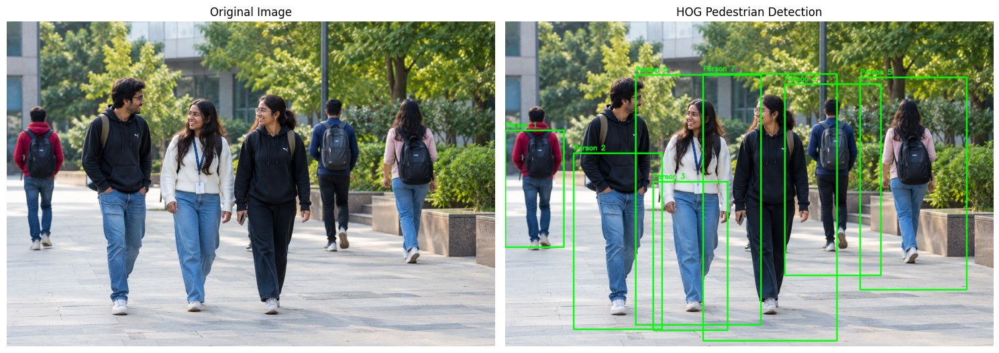

Vanshika Dhiman(CU24250228)


In [3]:
import cv2
import matplotlib.pyplot as plt

image_path = "people.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found. Check the file path.")
else:

    # Convert BGR to RGB for displaying
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------
    # 2. Create HOG pedestrian detector
    # ---------------------------------------------------

    hog = cv2.HOGDescriptor()

    # Use OpenCV's pre-trained SVM detector
    hog.setSVMDetector(
        cv2.HOGDescriptor_getDefaultPeopleDetector()
    )

    # ---------------------------------------------------
    # 3. Detect people
    # ---------------------------------------------------

    boxes, weights = hog.detectMultiScale(
        image,
        winStride=(8, 8),
        padding=(8, 8),
        scale=1.05
    )

    print("Number of pedestrians detected:", len(boxes))

    # ---------------------------------------------------
    # 4. Draw bounding boxes
    # ---------------------------------------------------

    result = image.copy()

    for i, (x, y, w, h) in enumerate(boxes):

        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            3
        )

        cv2.putText(
            result,
            f"Person {i + 1}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    # Convert result to RGB
    result_rgb = cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )

    # ---------------------------------------------------
    # 5. Display original and detected images
    # ---------------------------------------------------

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result_rgb)
    plt.title("HOG Pedestrian Detection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
print("Vanshika Dhiman(CU24250228)")

6. Create a HOG visulaizer that overlays the gradient-orientation histogram grid on top of an image.

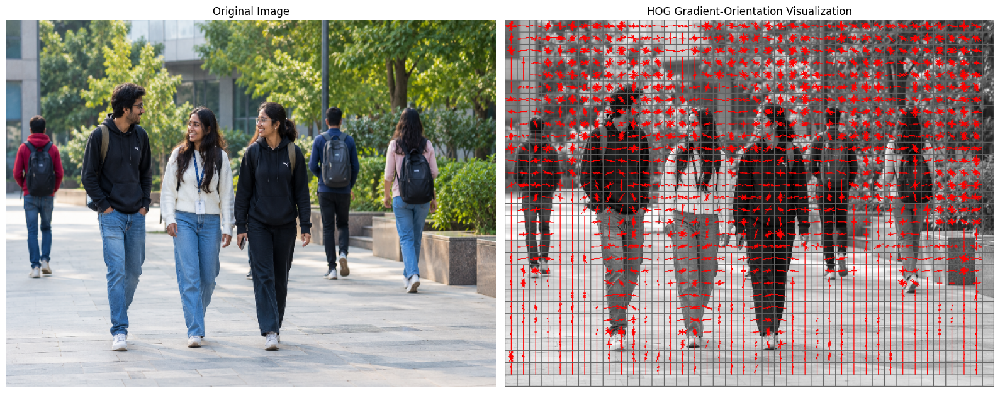

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Load image
# ---------------------------------------------------

image = cv2.imread("people.jpg")

if image is None:
    print("Error: people.jpg not found.")
else:

    # Resize for easier visualization
    image = cv2.resize(image, (640, 480))

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # ---------------------------------------------------
    # 2. Calculate image gradients
    # ---------------------------------------------------

    gx = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    gy = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    # Gradient magnitude
    magnitude = np.sqrt(gx**2 + gy**2)

    # Gradient orientation
    orientation = np.rad2deg(
        np.arctan2(gy, gx)
    )

    # Convert angles to range 0-180
    orientation = orientation % 180

    # ---------------------------------------------------
    # 3. Create image for visualization
    # ---------------------------------------------------

    output = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2RGB
    )

    # HOG cell size
    cell_size = 16

    # Number of orientation bins
    bins = 9

    # Bin width
    bin_width = 180 / bins

    height, width = gray.shape

    # ---------------------------------------------------
    # 4. Draw HOG cell grid
    # ---------------------------------------------------

    for y in range(0, height, cell_size):

        for x in range(0, width, cell_size):

            # Draw cell boundary
            cv2.rectangle(
                output,
                (x, y),
                (
                    min(x + cell_size, width - 1),
                    min(y + cell_size, height - 1)
                ),
                (100, 100, 100),
                1
            )

    # ---------------------------------------------------
    # 5. Calculate and draw orientation histograms
    # ---------------------------------------------------

    for y in range(0, height - cell_size, cell_size):

        for x in range(0, width - cell_size, cell_size):

            cell_mag = magnitude[
                y:y + cell_size,
                x:x + cell_size
            ]

            cell_ori = orientation[
                y:y + cell_size,
                x:x + cell_size
            ]

            # Histogram for this cell
            histogram = np.zeros(bins)

            # Add magnitude to corresponding orientation bin
            for i in range(cell_size):
                for j in range(cell_size):

                    angle = cell_ori[i, j]
                    mag = cell_mag[i, j]

                    bin_index = int(
                        angle // bin_width
                    )

                    if bin_index >= bins:
                        bin_index = bins - 1

                    histogram[bin_index] += mag

            # Normalize histogram
            if histogram.max() > 0:
                histogram = histogram / histogram.max()

            # Center of cell
            cx = x + cell_size // 2
            cy = y + cell_size // 2

            # Draw each orientation
            for b in range(bins):

                angle = (
                    b * bin_width +
                    bin_width / 2
                )

                # Convert angle to radians
                theta = np.deg2rad(angle)

                # Length based on histogram magnitude
                length = (
                    histogram[b] *
                    cell_size *
                    0.45
                )

                # Calculate line endpoints
                dx = int(
                    length * np.cos(theta)
                )

                dy = int(
                    length * np.sin(theta)
                )

                # Draw gradient orientation line
                cv2.line(
                    output,
                    (cx - dx, cy - dy),
                    (cx + dx, cy + dy),
                    (255, 0, 0),
                    1
                )

    # ---------------------------------------------------
    # 6. Display results
    # ---------------------------------------------------

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(16, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output)
    plt.title("HOG Gradient-Orientation Visualization")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

7. Biild a duplicate /  near duplicate image detector using SIFT feature similarity scoring.

Keypoints in Image 1: 1432
Keypoints in Image 2: 1969
Good matches: 34

SIFT Similarity Score: 2.37%
Result: Different Images


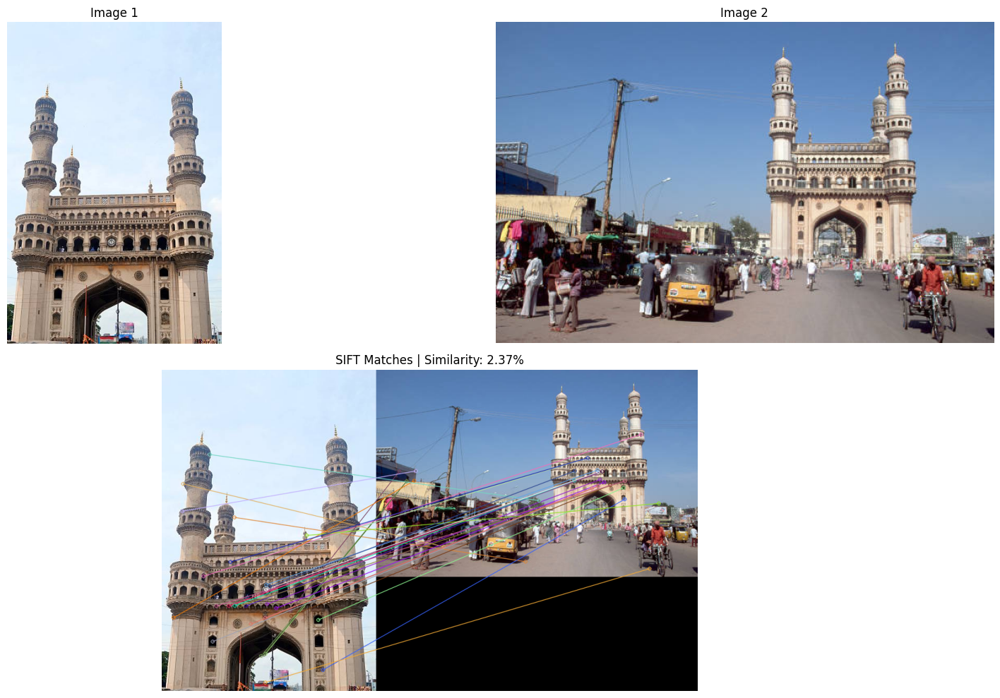

Vanshika Dhiman


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Load the two images
# ---------------------------------------------------

image1 = cv2.imread("charminar1.jpg")
image2 = cv2.imread("charminar2.jpg")

if image1 is None or image2 is None:
    print("Error: Could not load one or both images.")

else:

    # Convert to grayscale
    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # ---------------------------------------------------
    # 2. Create SIFT detector
    # ---------------------------------------------------

    sift = cv2.SIFT_create()

    # Detect keypoints and descriptors
    keypoints1, descriptors1 = sift.detectAndCompute(
        gray1, None
    )

    keypoints2, descriptors2 = sift.detectAndCompute(
        gray2, None
    )

    print("Keypoints in Image 1:", len(keypoints1))
    print("Keypoints in Image 2:", len(keypoints2))

    # ---------------------------------------------------
    # 3. Match SIFT descriptors
    # ---------------------------------------------------

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(
        descriptors1,
        descriptors2,
        k=2
    )

    # ---------------------------------------------------
    # 4. Apply Lowe's ratio test
    # ---------------------------------------------------

    good_matches = []

    for m, n in matches:

        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    print("Good matches:", len(good_matches))

    # ---------------------------------------------------
    # 5. Calculate similarity score
    # ---------------------------------------------------

    # Percentage of good matches relative to
    # the smaller number of detected keypoints
    min_keypoints = min(
        len(keypoints1),
        len(keypoints2)
    )

    if min_keypoints > 0:
        similarity = (
            len(good_matches) /
            min_keypoints
        ) * 100
    else:
        similarity = 0

    print(
        f"\nSIFT Similarity Score: {similarity:.2f}%"
    )

    # ---------------------------------------------------
    # 6. Classify images
    # ---------------------------------------------------

    if similarity >= 40:
        result = "Duplicate / Near-Duplicate"
    elif similarity >= 20:
        result = "Possibly Similar"
    else:
        result = "Different Images"

    print("Result:", result)

    # ---------------------------------------------------
    # 7. Draw matching features
    # ---------------------------------------------------

    good_matches = sorted(
        good_matches,
        key=lambda x: x.distance
    )

    match_image = cv2.drawMatches(
        image1,
        keypoints1,
        image2,
        keypoints2,
        good_matches[:50],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Convert BGR to RGB
    match_image_rgb = cv2.cvtColor(
        match_image,
        cv2.COLOR_BGR2RGB
    )

    # ---------------------------------------------------
    # 8. Display images and matches
    # ---------------------------------------------------

    image1_rgb = cv2.cvtColor(
        image1,
        cv2.COLOR_BGR2RGB
    )

    image2_rgb = cv2.cvtColor(
        image2,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(image1_rgb)
    plt.title("Image 1")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(image2_rgb)
    plt.title("Image 2")
    plt.axis("off")

    plt.subplot(2, 1, 2)
    plt.imshow(match_image_rgb)
    plt.title(
        f"SIFT Matches | Similarity: {similarity:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    print("Vanshika Dhiman")

8. Develop a rotation/scale invariance tester that verifies SIFT keypoints remain consistent under image transformation.

Keypoints detected:
-----------------------------
Original : 7030
Rotated  : 5320
Scaled   : 6699

SIFT Invariance Results:
-----------------------------
Rotation matching score: 71.15%
Scale matching score: 83.91%


/tmp/ipykernel_1776/2992357381.py:269: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


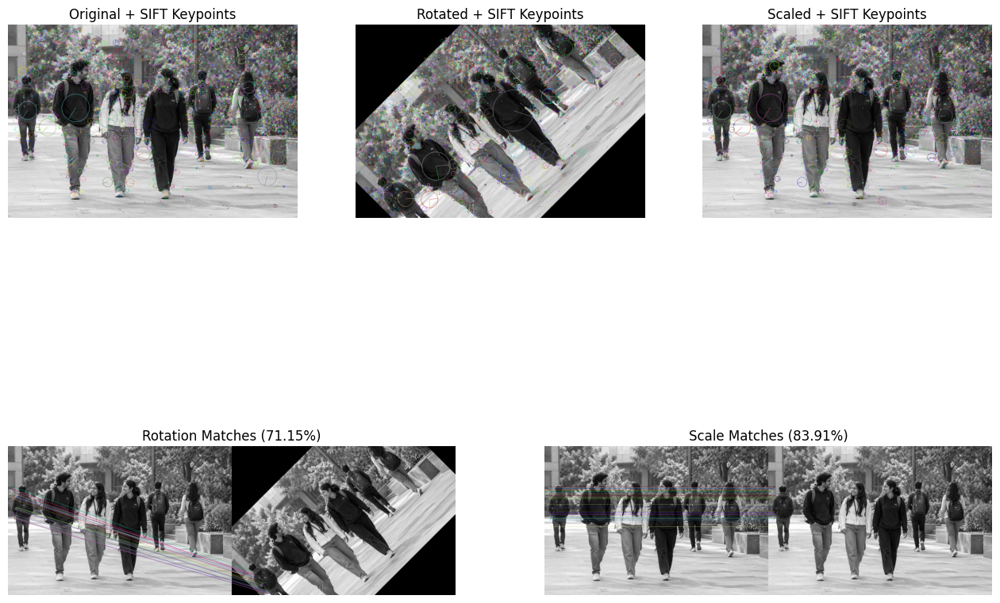

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Load original image
# ---------------------------------------------------

image = cv2.imread("people.jpg")

if image is None:
    print("Error: people.jpg not found.")
else:

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # ---------------------------------------------------
    # 2. Create rotated image
    # ---------------------------------------------------

    h, w = gray.shape

    center = (w // 2, h // 2)

    # Rotate by 45 degrees
    rotation_matrix = cv2.getRotationMatrix2D(
        center,
        45,
        1.0
    )

    rotated = cv2.warpAffine(
        gray,
        rotation_matrix,
        (w, h)
    )

    # ---------------------------------------------------
    # 3. Create scaled image
    # ---------------------------------------------------

    scale_factor = 1.5

    scaled = cv2.resize(
        gray,
        None,
        fx=scale_factor,
        fy=scale_factor,
        interpolation=cv2.INTER_LINEAR
    )

    # Resize scaled image back to original size
    scaled = cv2.resize(
        scaled,
        (w, h)
    )

    # ---------------------------------------------------
    # 4. Create SIFT detector
    # ---------------------------------------------------

    sift = cv2.SIFT_create()

    # Detect keypoints
    kp_original, des_original = sift.detectAndCompute(
        gray,
        None
    )

    kp_rotated, des_rotated = sift.detectAndCompute(
        rotated,
        None
    )

    kp_scaled, des_scaled = sift.detectAndCompute(
        scaled,
        None
    )

    # ---------------------------------------------------
    # 5. Print number of keypoints
    # ---------------------------------------------------

    print("Keypoints detected:")
    print("-----------------------------")
    print("Original :", len(kp_original))
    print("Rotated  :", len(kp_rotated))
    print("Scaled   :", len(kp_scaled))

    # ---------------------------------------------------
    # 6. Match original with rotated image
    # ---------------------------------------------------

    bf = cv2.BFMatcher()

    matches_rotation = bf.knnMatch(
        des_original,
        des_rotated,
        k=2
    )

    good_rotation = []

    for m, n in matches_rotation:
        if m.distance < 0.75 * n.distance:
            good_rotation.append(m)

    # ---------------------------------------------------
    # 7. Match original with scaled image
    # ---------------------------------------------------

    matches_scale = bf.knnMatch(
        des_original,
        des_scaled,
        k=2
    )

    good_scale = []

    for m, n in matches_scale:
        if m.distance < 0.75 * n.distance:
            good_scale.append(m)

    # ---------------------------------------------------
    # 8. Calculate consistency scores
    # ---------------------------------------------------

    rotation_score = (
        len(good_rotation) /
        max(1, min(
            len(kp_original),
            len(kp_rotated)
        ))
    ) * 100

    scale_score = (
        len(good_scale) /
        max(1, min(
            len(kp_original),
            len(kp_scaled)
        ))
    ) * 100

    print("\nSIFT Invariance Results:")
    print("-----------------------------")
    print(
        f"Rotation matching score: "
        f"{rotation_score:.2f}%"
    )
    print(
        f"Scale matching score: "
        f"{scale_score:.2f}%"
    )

    # ---------------------------------------------------
    # 9. Draw keypoints
    # ---------------------------------------------------

    original_kp = cv2.drawKeypoints(
        gray,
        kp_original,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    rotated_kp = cv2.drawKeypoints(
        rotated,
        kp_rotated,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    scaled_kp = cv2.drawKeypoints(
        scaled,
        kp_scaled,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    # ---------------------------------------------------
    # 10. Draw feature matches
    # ---------------------------------------------------

    rotation_matches_img = cv2.drawMatches(
        gray,
        kp_original,
        rotated,
        kp_rotated,
        good_rotation[:30],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    scale_matches_img = cv2.drawMatches(
        gray,
        kp_original,
        scaled,
        kp_scaled,
        good_scale[:30],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # ---------------------------------------------------
    # 11. Convert BGR to RGB
    # ---------------------------------------------------

    original_kp = cv2.cvtColor(
        original_kp,
        cv2.COLOR_BGR2RGB
    )

    rotated_kp = cv2.cvtColor(
        rotated_kp,
        cv2.COLOR_BGR2RGB
    )

    scaled_kp = cv2.cvtColor(
        scaled_kp,
        cv2.COLOR_BGR2RGB
    )

    rotation_matches_img = cv2.cvtColor(
        rotation_matches_img,
        cv2.COLOR_BGR2RGB
    )

    scale_matches_img = cv2.cvtColor(
        scale_matches_img,
        cv2.COLOR_BGR2RGB
    )

    # ---------------------------------------------------
    # 12. Display results
    # ---------------------------------------------------

    plt.figure(figsize=(16, 12))

    plt.subplot(2, 3, 1)
    plt.imshow(original_kp)
    plt.title("Original + SIFT Keypoints")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(rotated_kp)
    plt.title("Rotated + SIFT Keypoints")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(scaled_kp)
    plt.title("Scaled + SIFT Keypoints")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(rotation_matches_img)
    plt.title(
        f"Rotation Matches ({rotation_score:.2f}%)"
    )
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(scale_matches_img)
    plt.title(
        f"Scale Matches ({scale_score:.2f}%)"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

9. Create a simple image-retrieval system that ranks a small image database by SIFT feature similarity to a query image.

Query image keypoints: 1969
Could not load: img4.jpg
Could not load: img5.jpg

IMAGE RETRIEVAL RESULTS
Rank 1: charminar1.jpg -> Similarity: 1.82%
Rank 2: img2.jpg -> Similarity: 0.66%
Rank 3: people.jpg -> Similarity: 0.20%


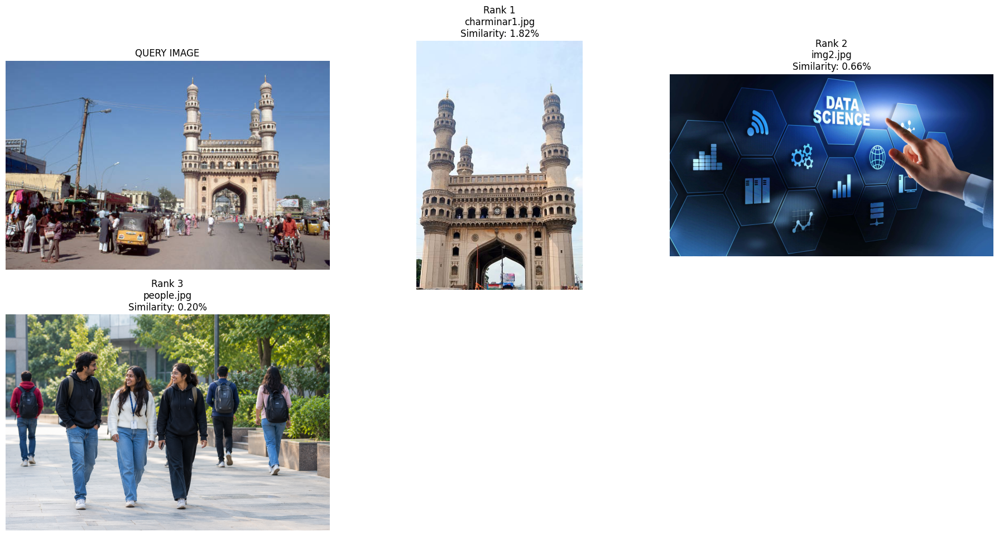

Vanshika Dhiman


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Image paths
# ---------------------------------------------------

query_path = "charminar2.jpg"

database_paths = [
    "charminar1.jpg",
    "img2.jpg",
    "people.jpg",
    "img4.jpg",
    "img5.jpg"
]

# ---------------------------------------------------
# 2. Load query image
# ---------------------------------------------------

query_image = cv2.imread(query_path)

if query_image is None:
    print("Error: query.jpg not found.")

else:

    # Convert query to grayscale
    query_gray = cv2.cvtColor(
        query_image,
        cv2.COLOR_BGR2GRAY
    )

    # ---------------------------------------------------
    # 3. Create SIFT detector
    # ---------------------------------------------------

    sift = cv2.SIFT_create()

    # Detect query keypoints and descriptors
    query_kp, query_des = sift.detectAndCompute(
        query_gray,
        None
    )

    print("Query image keypoints:", len(query_kp))

    # ---------------------------------------------------
    # 4. Create BF Matcher
    # ---------------------------------------------------

    bf = cv2.BFMatcher()

    results = []

    # ---------------------------------------------------
    # 5. Compare query with every database image
    # ---------------------------------------------------

    for path in database_paths:

        image = cv2.imread(path)

        if image is None:
            print("Could not load:", path)
            continue

        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )

        # Detect SIFT features
        kp, des = sift.detectAndCompute(
            gray,
            None
        )

        # Skip images without descriptors
        if des is None or query_des is None:
            similarity = 0
            good_matches = []

        else:

            # Find two nearest matches
            matches = bf.knnMatch(
                query_des,
                des,
                k=2
            )

            # Lowe's ratio test
            good_matches = []

            for m, n in matches:

                if m.distance < 0.75 * n.distance:
                    good_matches.append(m)

            # ---------------------------------------------------
            # Similarity score
            # ---------------------------------------------------

            min_keypoints = min(
                len(query_kp),
                len(kp)
            )

            if min_keypoints > 0:
                similarity = (
                    len(good_matches) /
                    min_keypoints
                ) * 100
            else:
                similarity = 0

        # Store result
        results.append(
            (
                path,
                similarity,
                image,
                kp,
                good_matches
            )
        )

    # ---------------------------------------------------
    # 6. Rank images
    # ---------------------------------------------------

    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # ---------------------------------------------------
    # 7. Print ranking
    # ---------------------------------------------------

    print("\nIMAGE RETRIEVAL RESULTS")
    print("=" * 50)

    for rank, result in enumerate(
        results,
        start=1
    ):

        path = result[0]
        score = result[1]

        print(
            f"Rank {rank}: "
            f"{path} "
            f"-> Similarity: {score:.2f}%"
        )

    # ---------------------------------------------------
    # 8. Display ranked images
    # ---------------------------------------------------

    plt.figure(figsize=(18, 10))

    # Display query image
    plt.subplot(2, 3, 1)

    query_rgb = cv2.cvtColor(
        query_image,
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(query_rgb)
    plt.title("QUERY IMAGE")
    plt.axis("off")

    # Display top 5 results
    for i, result in enumerate(results[:5]):

        path = result[0]
        score = result[1]
        image = result[2]

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(2, 3, i + 2)

        plt.imshow(image_rgb)

        plt.title(
            f"Rank {i + 1}\n"
            f"{path}\n"
            f"Similarity: {score:.2f}%"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()
print("Vanshika Dhiman")

10. Build a benchmarking tool comparing SIFT versus HOG descriptors on a basic object-recognition task.

Total images loaded: 5

       SIFT vs HOG BENCHMARK

SIFT
------------------------------
Recognition Accuracy : 40.0 %
Average Time         : 866.57 ms

HOG
------------------------------
Recognition Accuracy : 40.0 %
Average Time         : 21.19 ms


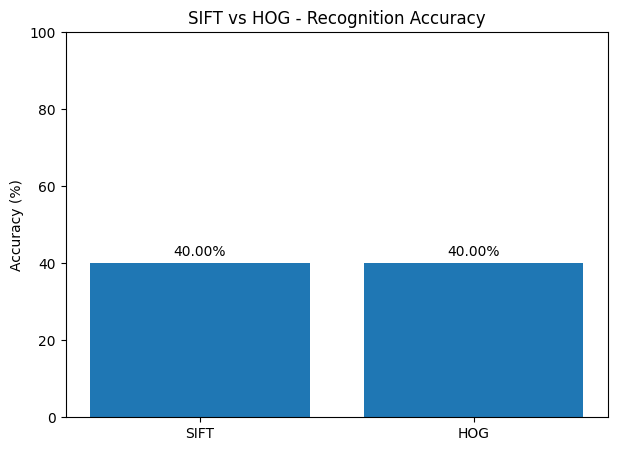

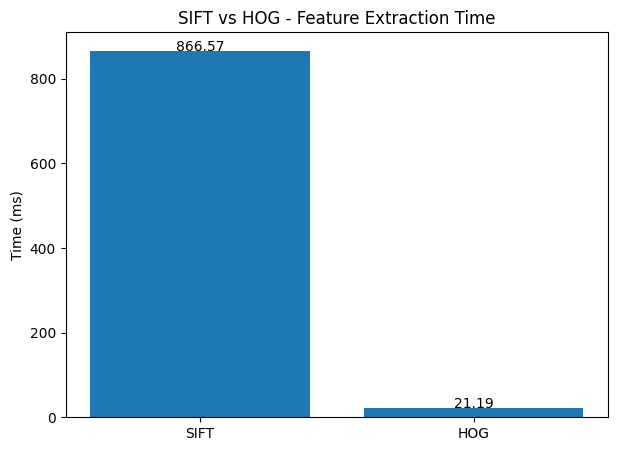

Vanshika Dhiman


In [13]:
import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt

image_files = [
    "cup1.jpg",
    "cup2.jpg",
    "cup3.jpg",
    "book1.jpg",
    "book2.jpg"
]

# Labels according to the images
labels = [
    "Cup",
    "Cup",
    "Cup",
    "Book",
    "Book"
]

# ============================================================
# SIFT FEATURE EXTRACTION
# ============================================================

sift = cv2.SIFT_create()

def extract_sift(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    start = time.time()

    keypoints, descriptors = sift.detectAndCompute(gray, None)

    elapsed = time.time() - start

    if descriptors is None:
        return None, elapsed

    # Convert SIFT descriptors into one fixed-size feature
    feature = np.mean(descriptors, axis=0)

    return feature, elapsed


# ============================================================
# HOG FEATURE EXTRACTION
# ============================================================

def extract_hog(image):

    start = time.time()

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))

    # Calculate gradients
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    magnitude = cv2.magnitude(gx, gy)
    angle = cv2.phase(gx, gy, angleInDegrees=True)

    cell_size = 8
    bins = 9

    feature = []

    # Create HOG histogram for each cell
    for y in range(0, 128, cell_size):
        for x in range(0, 128, cell_size):

            cell_mag = magnitude[y:y+cell_size, x:x+cell_size]
            cell_angle = angle[y:y+cell_size, x:x+cell_size]

            histogram = np.zeros(bins)

            for i in range(cell_mag.shape[0]):
                for j in range(cell_mag.shape[1]):

                    a = cell_angle[i, j] % 180
                    m = cell_mag[i, j]

                    bin_index = int(a / 20)

                    if bin_index >= bins:
                        bin_index = bins - 1

                    histogram[bin_index] += m

            feature.extend(histogram)

    elapsed = time.time() - start

    return np.array(feature), elapsed


# ============================================================
# LOAD IMAGES
# ============================================================

images = []
valid_labels = []

for filename, label in zip(image_files, labels):

    image = cv2.imread(filename)

    if image is None:
        print("Image not found:", filename)
        continue

    images.append(image)
    valid_labels.append(label)

print("Total images loaded:", len(images))


# ============================================================
# EXTRACT FEATURES
# ============================================================

sift_features = []
hog_features = []

sift_times = []
hog_times = []

for image in images:

    # SIFT
    sift_feature, sift_time = extract_sift(image)

    # HOG
    hog_feature, hog_time = extract_hog(image)

    if sift_feature is not None:

        sift_features.append(sift_feature)
        hog_features.append(hog_feature)

        sift_times.append(sift_time)
        hog_times.append(hog_time)


sift_features = np.array(sift_features)
hog_features = np.array(hog_features)


# ============================================================
# NEAREST-NEIGHBOR CLASSIFICATION
# ============================================================

def calculate_accuracy(features, labels):

    correct = 0
    total = len(features)

    for i in range(total):

        best_distance = float("inf")
        predicted_label = None

        for j in range(total):

            if i == j:
                continue

            distance = np.linalg.norm(
                features[i] - features[j]
            )

            if distance < best_distance:
                best_distance = distance
                predicted_label = labels[j]

        if predicted_label == labels[i]:
            correct += 1

    if total <= 1:
        return 0

    return (correct / total) * 100


# ============================================================
# CALCULATE RESULTS
# ============================================================

sift_accuracy = calculate_accuracy(
    sift_features,
    valid_labels
)

hog_accuracy = calculate_accuracy(
    hog_features,
    valid_labels
)

avg_sift_time = np.mean(sift_times) * 1000
avg_hog_time = np.mean(hog_times) * 1000


# ============================================================
# DISPLAY BENCHMARK RESULTS
# ============================================================

print("\n" + "=" * 50)
print("       SIFT vs HOG BENCHMARK")
print("=" * 50)

print("\nSIFT")
print("-" * 30)
print("Recognition Accuracy :", round(sift_accuracy, 2), "%")
print("Average Time         :", round(avg_sift_time, 2), "ms")

print("\nHOG")
print("-" * 30)
print("Recognition Accuracy :", round(hog_accuracy, 2), "%")
print("Average Time         :", round(avg_hog_time, 2), "ms")


# ============================================================
# ACCURACY GRAPH
# ============================================================

methods = ["SIFT", "HOG"]
accuracy = [sift_accuracy, hog_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(methods, accuracy)

plt.title("SIFT vs HOG - Recognition Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(accuracy):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()


# ============================================================
# PROCESSING TIME GRAPH
# ============================================================

times = [avg_sift_time, avg_hog_time]

plt.figure(figsize=(7, 5))
plt.bar(methods, times)

plt.title("SIFT vs HOG - Feature Extraction Time")
plt.ylabel("Time (ms)")

for i, value in enumerate(times):
    plt.text(i, value + 0.05, f"{value:.2f}", ha="center")

plt.show()
print("Vanshika Dhiman")